# Galerie des corps : les 4 designs de plasticite

Meme chose que l'action `compare and save` de `exp/exp25.py` et `exp/exp26.py`,
mais tout est assemble sur une seule figure matplotlib au lieu d'etre sauve en images separees.

Il y a **une fonction par design**, ecrite a plat, qui reprend les noms `Xs / Ys / Zs / Ws` :

| fonction du notebook | ce qu'elle refait | `Ys` (`new_before`) vient de |
|---|---|---|
| `section_haploid_dev()`   | exp25, `compare_render_now_and_before`, haploid | le **CPPN** relu avec l'entree de l'autre env |
| `section_diploid_dev()`   | exp25, `compare_render_now_and_before`, diploid | le **CPPN** relu avec l'entree de l'autre env |
| `section_haploid_chrom()` | exp26, `compare_hap_chrom_render_now_and_before` | **rien**, un haploide n'a qu'un chromosome |
| `section_diploid_chrom()` | exp26, `compare_chrom_render_now_and_before`   | le **genome**, l'autre chromosome s'exprime |

La figure est un carre de 4 sections :

|  | haploid | diploid |
|---|---|---|
| **developmental plasticity** | en haut a gauche | en haut a droite |
| **chromosomal plasticity**   | en bas a gauche  | en bas a droite  |

et dans chaque section les 4 cas sont eux aussi en carre :

|  | environnement courant | autre environnement |
|---|---|---|
| **genome d'aujourd'hui** | `Xs` = now | `Ys` = now re-expressed |
| **individus passes**     | `Ws` = double before | `Zs` = before |

## 1. Reglages

Tout ce qui se change est ici : les 4 chemins, les 4 generations, les titres,
les legendes, les couleurs, les tailles.

In [106]:
# =============================================================================
#  REGLAGES  -  tout se change ici, rien a toucher plus bas
# =============================================================================

# ---- design 1 : haploid, developmental plasticity   (en haut a gauche) ------
PATH_HAP_DEV  = 'results/paper-dev-pw/id_7/haploid'
GEN_HAP_DEV   = 400
TITLE_HAP_DEV = 'Haploid  -  developmental plasticity'

# ---- design 2 : diploid, developmental plasticity   (en haut a droite) -----
PATH_DIP_DEV  = 'results/paper-dev-pw/id_8/diploid'
GEN_DIP_DEV   = 400
TITLE_DIP_DEV = 'Diploid  -  developmental plasticity'

# ---- design 3 : haploid, chromosomal plasticity     (en bas a gauche) ------
PATH_HAP_CHROM  = 'results/paper-chrom-pw/id_7/haploid'
GEN_HAP_CHROM   = 400
TITLE_HAP_CHROM = 'Haploid  -  chromosomal plasticity'

# ---- design 4 : diploid, chromosomal plasticity     (en bas a droite) ------
PATH_DIP_CHROM  = 'results/paper-chrom-pw/id_10/diploid'
GEN_DIP_CHROM   = 400
TITLE_DIP_CHROM = 'Diploid  -  chromosomal plasticity'


# ---- combien de robots par cas ----------------------------------------------
# 1 -> seulement le meilleur, donc un robot dans chaque coin du carre
# n -> les n meilleurs, empiles en colonne sous la legende du cas
N_ROBOTS = 1


# ---- les legendes des 4 cas  ({gen} = la generation, {env} = l'environnement)
LABEL_NOW           = 'now\ngen {gen}, {env}'
LABEL_NEW_BEFORE    = 'now re-expressed\n{env}'
LABEL_BEFORE        = 'before\ngen {gen}, {env}'
LABEL_DOUBLE_BEFORE = 'double before\ngen {gen}, {env}'

# ce qu'on ecrit dans un coin vide
# (le haploid chromosomal n'a pas de re-expression, son coin 'new_before' reste vide)
TEXT_EMPTY_CORNER = '-'


# ---- titre de la figure ------------------------------------------------------
FIG_TITLE = 'Best bodies across the four plasticity designs'


# ---- couleurs des voxels (code couleur EvoGym) -------------------------------
VOXEL_COLORS = ['#ffffff', '#1a1a1a', '#b5b5b5', '#e8833a', '#5b9bd5']
VOXEL_NAMES  = ['empty', 'rigid', 'soft', 'horizontal actuator', 'vertical actuator']
SHOW_VOXEL_LEGEND = True

GRID_COLOR   = '#d0d0d0'   # le quadrillage entre les voxels
BORDER_COLOR = '#909090'   # le cadre autour d'un corps


# ---- tailles -------------------------------------------------------------------
FIG_WIDTH  = 9.0
FIG_HEIGHT = 8.0

TITLE_SIZE         = 15
SECTION_TITLE_SIZE = 12
CASE_LABEL_SIZE    = 9
LEGEND_SIZE        = 9


# ---- sauvegarde -----------------------------------------------------------------
SAVE      = True
SAVE_PATH = 'figures/bodies_four_designs.pdf'   # relatif au dossier results_analysis
SAVE_DPI  = 300

## 2. Imports et petites fonctions communes

In [107]:
import os
import sys
import json
import dill
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from base_fns import get_local_file

file = get_local_file()
local_dir = os.path.dirname(os.path.dirname(file))
sys.path.append(local_dir)

from config import Config
from components import CPPNComponent, BodyNetworkComponent
from tools.network_manager import NetworkManager
from tools.substrate import SubstrateBuilder
from tools.hyper_encoding import PhenotypeBuilder
from tools.genome_operator import GenomeOperator

N_VOXEL_TYPES = 5
BODY_BIAS = np.sqrt(2) / 2   # la meme entree que dans RobotGenerator


def read_config(path):
    # le configs.json du run
    with open(os.path.join(local_dir, path, 'json', 'configs.json'), 'r') as f:
        return Config(json.load(f))


def read_registry(path, generation, name):
    # un pkl du type '<generation>_<name>.pkl'
    pkl = os.path.join(local_dir, path, 'pkl', '{}_{}.pkl'.format(generation, name))
    with open(pkl, 'rb') as f:
        return dill.load(f)


def best_keys(fitness_registry, how_many):
    # les cles des 'how_many' meilleurs individus, du meilleur au moins bon.
    # C'est la transcription exacte de la fonction tops() de tes compare_*,
    # y compris le np.argsort : il departage les ex aequo de la meme facon.
    keys = []
    for key in fitness_registry.keys():
        if fitness_registry[key].fitness > -1000:
            keys.append(key)

    fitnesses = np.array([fitness_registry[key].fitness for key in keys])
    order = np.argsort(fitnesses)

    bests = []
    for taken in range(min(how_many, len(keys))):
        index = order[len(keys) - 1 - taken]
        bests.append(keys[index])
    return bests


def reference_generations(config, generation):
    # les 2 generations de reference et les 2 environnements, comme dans exp25 / exp26
    gen_before = (generation // config.switch) * config.switch - 1
    gen_double = ((generation // config.switch) - 1) * config.switch - 1
    env_now = 0 if (generation // config.switch) % 2 == 0 else 1
    env_before = 1 - env_now
    return gen_before, gen_double, env_now, env_before


def build_tools(config):
    # les objets du projet dont on a besoin pour re-exprimer un genome
    substrate_builder = SubstrateBuilder(config)
    substrate = substrate_builder.shape_into_coordinates(
        substrate_builder.extract_former_body_network_shape(config))
    return {
        'config':            config,
        'substrate':         substrate,
        'network_manager':   NetworkManager(config),
        'phenotype_builder': PhenotypeBuilder(),
        'genome_operator':   GenomeOperator(config),
    }

## 3. Les deux facons de redessiner un corps

La difference entre les deux designs tient entierement a ces deux fonctions.

In [108]:
def body_from_cppn(cppn, env, tools):
    # Le corps dessine par un CPPN sous l'environnement 'env'.
    # C'est ce que fait exp25 : phenotype_builder puis
    # robot_generator.generate_former_robot_body_from_network_and_env,
    # ou l'environnement entre dans le reseau par le SIGNE de l'entree.
    config = tools['config']

    node_evals, in_nodes, out_nodes = tools['phenotype_builder'].create_phenotype_network_without_bias_2_outputs(
        cppn, tools['network_manager'], tools['substrate'],
        np.tanh, np.tanh, sum,
        config.response, config.max_weight, config.max_bias, type_output=0)
    body_network = BodyNetworkComponent(node_evals, in_nodes, out_nodes)

    if env == 0:
        entry = BODY_BIAS
    else:
        entry = -BODY_BIAS

    outputs = tools['network_manager'].activate(body_network, [entry])
    formated = np.reshape(outputs, (config.body_shape[0], config.body_shape[1], N_VOXEL_TYPES))
    return np.argmax(formated, 2)


def body_from_diploid_genome(genome, env, tools):
    # Le corps dessine par un genome DIPLOIDE sous le signal 'env'.
    # C'est ce que fait exp26 : le signal choisit d'abord quel chromosome s'exprime,
    # puis le CPPN obtenu est lu avec une entree qui, elle, ne change jamais
    # (robot_generator.generate_former_one_signal_robot_body_from_network_and_env).
    config = tools['config']

    connections, bias, functions = tools['genome_operator'].signal_uniform_dominance_with_modu_regu(genome, env)
    node_evals, in_nodes, out_nodes = tools['network_manager'].create_network_with_modu_regu(
        genome.nodes, connections, bias, functions, sum, response=1)
    cppn = CPPNComponent(node_evals, in_nodes, out_nodes)

    node_evals, in_nodes, out_nodes = tools['phenotype_builder'].create_phenotype_network_without_bias_2_outputs(
        cppn, tools['network_manager'], tools['substrate'],
        np.tanh, np.tanh, sum,
        config.response, config.max_weight, config.max_bias, type_output=0)
    body_network = BodyNetworkComponent(node_evals, in_nodes, out_nodes)

    outputs = tools['network_manager'].activate(body_network, [BODY_BIAS])
    formated = np.reshape(outputs, (config.body_shape[0], config.body_shape[1], N_VOXEL_TYPES))
    return np.argmax(formated, 2)


def corner(label, bodies, generation, env_name):
    # un coin du carre : sa legende, et les corps a y dessiner
    return {'label': label.format(gen=generation, env=env_name), 'bodies': bodies}

## 4. Une fonction par design

Elles se ressemblent beaucoup, c'est voulu : chacune se lit toute seule,
de haut en bas, sans avoir a sauter ailleurs.

In [109]:
def section_haploid_dev():
    # exp25.py, action 'compare and save', type_genome = 'haploid'
    config = read_config(PATH_HAP_DEV)
    tools = build_tools(config)
    generation = GEN_HAP_DEV
    gen_before, gen_double, env_now, env_before = reference_generations(config, generation)

    keys_now    = best_keys(read_registry(PATH_HAP_DEV, generation, 'fitness_registry'), N_ROBOTS)
    keys_before = best_keys(read_registry(PATH_HAP_DEV, gen_before, 'fitness_registry'), N_ROBOTS)
    keys_double = best_keys(read_registry(PATH_HAP_DEV, gen_double, 'fitness_registry'), N_ROBOTS)

    bodies_now    = read_registry(PATH_HAP_DEV, generation, 'body_registry')
    bodies_before = read_registry(PATH_HAP_DEV, gen_before, 'body_registry')
    bodies_double = read_registry(PATH_HAP_DEV, gen_double, 'body_registry')
    cppns_now     = read_registry(PATH_HAP_DEV, generation, 'cppn_registry')

    Xs = [bodies_now[key].body for key in keys_now]
    Ys = [body_from_cppn(cppns_now[key], env_before, tools) for key in keys_now]
    Zs = [bodies_before[key].body for key in keys_before]
    Ws = [bodies_double[key].body for key in keys_double]

    return {
        'now':           corner(LABEL_NOW,           Xs, generation, config.env_name[env_now]),
        'new_before':    corner(LABEL_NEW_BEFORE,    Ys, generation, config.env_name[env_before]),
        'before':        corner(LABEL_BEFORE,        Zs, gen_before, config.env_name[env_before]),
        'double_before': corner(LABEL_DOUBLE_BEFORE, Ws, gen_double, config.env_name[env_now]),
    }


def section_diploid_dev():
    # exp25.py, action 'compare and save', type_genome = 'diploid'
    # (en plasticite developpementale, haploide et diploide se traitent pareil :
    #  c'est le CPPN sauve qui est relu, avec l'entree de l'autre environnement)
    config = read_config(PATH_DIP_DEV)
    tools = build_tools(config)
    generation = GEN_DIP_DEV
    gen_before, gen_double, env_now, env_before = reference_generations(config, generation)

    keys_now    = best_keys(read_registry(PATH_DIP_DEV, generation, 'fitness_registry'), N_ROBOTS)
    keys_before = best_keys(read_registry(PATH_DIP_DEV, gen_before, 'fitness_registry'), N_ROBOTS)
    keys_double = best_keys(read_registry(PATH_DIP_DEV, gen_double, 'fitness_registry'), N_ROBOTS)

    bodies_now    = read_registry(PATH_DIP_DEV, generation, 'body_registry')
    bodies_before = read_registry(PATH_DIP_DEV, gen_before, 'body_registry')
    bodies_double = read_registry(PATH_DIP_DEV, gen_double, 'body_registry')
    cppns_now     = read_registry(PATH_DIP_DEV, generation, 'cppn_registry')

    Xs = [bodies_now[key].body for key in keys_now]
    Ys = [body_from_cppn(cppns_now[key], env_before, tools) for key in keys_now]
    Zs = [bodies_before[key].body for key in keys_before]
    Ws = [bodies_double[key].body for key in keys_double]

    return {
        'now':           corner(LABEL_NOW,           Xs, generation, config.env_name[env_now]),
        'new_before':    corner(LABEL_NEW_BEFORE,    Ys, generation, config.env_name[env_before]),
        'before':        corner(LABEL_BEFORE,        Zs, gen_before, config.env_name[env_before]),
        'double_before': corner(LABEL_DOUBLE_BEFORE, Ws, gen_double, config.env_name[env_now]),
    }


def section_haploid_chrom():
    # exp26.py, action 'compare and save', type_genome = 'haploid'
    # Ta fonction compare_hap_chrom_render_now_and_before ne renvoie que Xs, Zs, Ws :
    # un haploide n'a qu'un seul chromosome, il n'y a donc rien a re-exprimer.
    # Le coin 'new_before' reste vide, mais on garde sa legende.
    config = read_config(PATH_HAP_CHROM)
    generation = GEN_HAP_CHROM
    gen_before, gen_double, env_now, env_before = reference_generations(config, generation)

    keys_now    = best_keys(read_registry(PATH_HAP_CHROM, generation, 'fitness_registry'), N_ROBOTS)
    keys_before = best_keys(read_registry(PATH_HAP_CHROM, gen_before, 'fitness_registry'), N_ROBOTS)
    keys_double = best_keys(read_registry(PATH_HAP_CHROM, gen_double, 'fitness_registry'), N_ROBOTS)

    bodies_now    = read_registry(PATH_HAP_CHROM, generation, 'body_registry')
    bodies_before = read_registry(PATH_HAP_CHROM, gen_before, 'body_registry')
    bodies_double = read_registry(PATH_HAP_CHROM, gen_double, 'body_registry')

    Xs = [bodies_now[key].body for key in keys_now]
    Ys = []
    Zs = [bodies_before[key].body for key in keys_before]
    Ws = [bodies_double[key].body for key in keys_double]

    return {
        'now':           corner(LABEL_NOW,           Xs, generation, config.env_name[env_now]),
        'new_before':    corner(LABEL_NEW_BEFORE,    Ys, generation, config.env_name[env_before]),
        'before':        corner(LABEL_BEFORE,        Zs, gen_before, config.env_name[env_before]),
        'double_before': corner(LABEL_DOUBLE_BEFORE, Ws, gen_double, config.env_name[env_now]),
    }


def section_diploid_chrom():
    # exp26.py, action 'compare and save', type_genome = 'diploid'
    # Ici Ys ne vient pas du CPPN sauve mais du GENOME : on change le signal,
    # donc l'autre chromosome s'exprime, et on redessine le corps.
    config = read_config(PATH_DIP_CHROM)
    tools = build_tools(config)
    generation = GEN_DIP_CHROM
    gen_before, gen_double, env_now, env_before = reference_generations(config, generation)

    keys_now    = best_keys(read_registry(PATH_DIP_CHROM, generation, 'fitness_registry'), N_ROBOTS)
    keys_before = best_keys(read_registry(PATH_DIP_CHROM, gen_before, 'fitness_registry'), N_ROBOTS)
    keys_double = best_keys(read_registry(PATH_DIP_CHROM, gen_double, 'fitness_registry'), N_ROBOTS)

    bodies_now    = read_registry(PATH_DIP_CHROM, generation, 'body_registry')
    bodies_before = read_registry(PATH_DIP_CHROM, gen_before, 'body_registry')
    bodies_double = read_registry(PATH_DIP_CHROM, gen_double, 'body_registry')
    genomes_now   = read_registry(PATH_DIP_CHROM, generation, 'genome_registry')

    Xs = [bodies_now[key].body for key in keys_now]
    Ys = [body_from_diploid_genome(genomes_now[key], env_before, tools) for key in keys_now]
    Zs = [bodies_before[key].body for key in keys_before]
    Ws = [bodies_double[key].body for key in keys_double]

    return {
        'now':           corner(LABEL_NOW,           Xs, generation, config.env_name[env_now]),
        'new_before':    corner(LABEL_NEW_BEFORE,    Ys, generation, config.env_name[env_before]),
        'before':        corner(LABEL_BEFORE,        Zs, gen_before, config.env_name[env_before]),
        'double_before': corner(LABEL_DOUBLE_BEFORE, Ws, gen_double, config.env_name[env_now]),
    }

## 5. Chargement

Cellule un peu longue, les pkl sont gros.

In [110]:
def empty_section():
    # de quoi dessiner une section quand les pkl du run ne sont pas la
    return {
        'now':           corner(LABEL_NOW,           [], '?', '?'),
        'new_before':    corner(LABEL_NEW_BEFORE,    [], '?', '?'),
        'before':        corner(LABEL_BEFORE,        [], '?', '?'),
        'double_before': corner(LABEL_DOUBLE_BEFORE, [], '?', '?'),
    }


def load_section(title, section_function):
    # si les pkl du run ne sont pas la, on dessine la section vide
    # plutot que de faire planter toute la figure
    try:
        section = section_function()
        print('ok   {}'.format(title))
        return section
    except FileNotFoundError as error:
        print('!!   {} : fichier manquant -> {}'.format(title, error.filename))
        return empty_section()


SECTION_HAP_DEV   = load_section(TITLE_HAP_DEV,   section_haploid_dev)
SECTION_DIP_DEV   = load_section(TITLE_DIP_DEV,   section_diploid_dev)
SECTION_HAP_CHROM = load_section(TITLE_HAP_CHROM, section_haploid_chrom)
SECTION_DIP_CHROM = load_section(TITLE_DIP_CHROM, section_diploid_chrom)

ok   Haploid  -  developmental plasticity
ok   Diploid  -  developmental plasticity
ok   Haploid  -  chromosomal plasticity
ok   Diploid  -  chromosomal plasticity


## 6. La figure

Pour changer un titre, une couleur ou une taille : modifier la cellule 1 puis
rejouer cette cellule. Pas besoin de recharger les pkl.

figure sauvee dans /home/vachermatteo/Documents/project/sgr-ecs-matteo/results_analysis/figures/bodies_four_designs.pdf


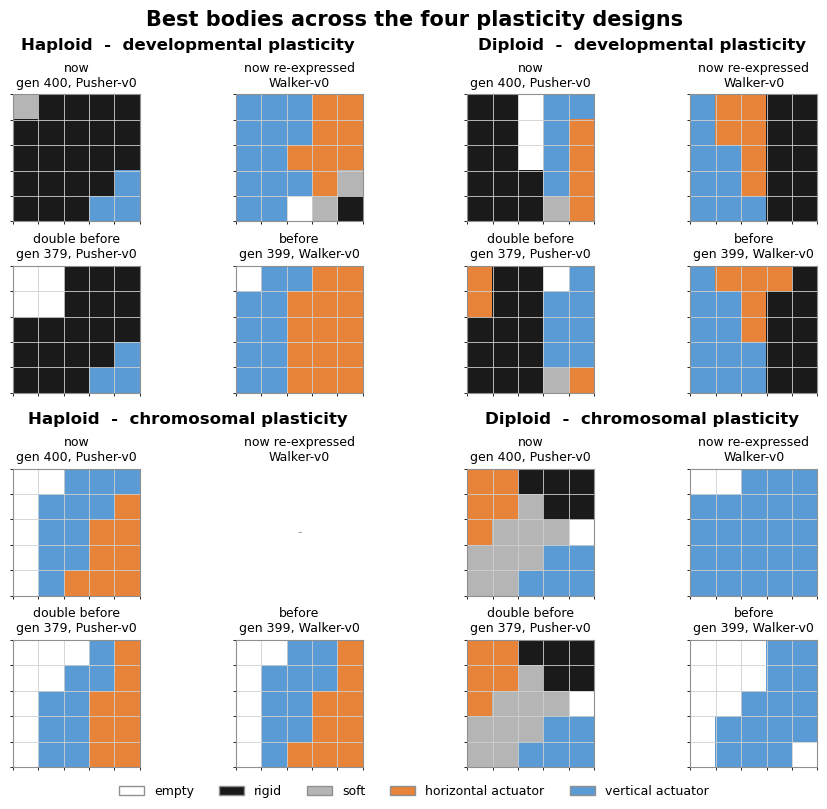

In [111]:
VOXEL_CMAP = ListedColormap(VOXEL_COLORS)


def draw_body(ax, body):
    # un corps = une grille de carres colores
    ax.imshow(body, cmap=VOXEL_CMAP, vmin=0, vmax=N_VOXEL_TYPES - 1)
    ax.set_xticks(np.arange(-0.5, body.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, body.shape[0], 1), minor=True)
    ax.grid(which='minor', color=GRID_COLOR, linewidth=0.6)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color(BORDER_COLOR)


def draw_empty(ax):
    # une case sans corps : pas de cadre, juste le petit texte
    ax.text(0.5, 0.5, TEXT_EMPTY_CORNER, ha='center', va='center',
            fontsize=CASE_LABEL_SIZE, color='#999999', transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


def draw_corner(axes, row, column, corner):
    # un coin du carre : la legende du cas, puis une colonne de N_ROBOTS corps
    for rank in range(N_ROBOTS):
        ax = axes[row * N_ROBOTS + rank][column]
        if rank < len(corner['bodies']):
            draw_body(ax, corner['bodies'][rank])
        else:
            draw_empty(ax)
    axes[row * N_ROBOTS][column].set_title(corner['label'], fontsize=CASE_LABEL_SIZE)


def draw_section(subfigure, title, top_left, top_right, bottom_left, bottom_right):
    # une section : son titre, et les 4 cas places en carre
    subfigure.suptitle(title, fontsize=SECTION_TITLE_SIZE, fontweight='bold')
    axes = subfigure.subplots(2 * N_ROBOTS, 2, squeeze=False)
    draw_corner(axes, 0, 0, top_left)
    draw_corner(axes, 0, 1, top_right)
    draw_corner(axes, 1, 0, bottom_left)
    draw_corner(axes, 1, 1, bottom_right)


def draw_voxel_legend(figure):
    handles = [Patch(facecolor=VOXEL_COLORS[voxel], edgecolor=BORDER_COLOR, label=VOXEL_NAMES[voxel])
               for voxel in range(N_VOXEL_TYPES)]
    figure.legend(handles=handles, loc='outside lower center', ncol=N_VOXEL_TYPES,
                  frameon=False, fontsize=LEGEND_SIZE)


figure = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), layout='constrained')
figure.suptitle(FIG_TITLE, fontsize=TITLE_SIZE, fontweight='bold')
subfigures = figure.subfigures(2, 2)

# Chaque appel dit noir sur blanc quel cas va dans quel coin.
# Pour deplacer un cas, il suffit d'echanger deux arguments ici.
draw_section(subfigures[0][0], TITLE_HAP_DEV,
             SECTION_HAP_DEV['now'],           SECTION_HAP_DEV['new_before'],
             SECTION_HAP_DEV['double_before'], SECTION_HAP_DEV['before'])

draw_section(subfigures[0][1], TITLE_DIP_DEV,
             SECTION_DIP_DEV['now'],           SECTION_DIP_DEV['new_before'],
             SECTION_DIP_DEV['double_before'], SECTION_DIP_DEV['before'])

draw_section(subfigures[1][0], TITLE_HAP_CHROM,
             SECTION_HAP_CHROM['now'],           SECTION_HAP_CHROM['new_before'],
             SECTION_HAP_CHROM['double_before'], SECTION_HAP_CHROM['before'])

draw_section(subfigures[1][1], TITLE_DIP_CHROM,
             SECTION_DIP_CHROM['now'],           SECTION_DIP_CHROM['new_before'],
             SECTION_DIP_CHROM['double_before'], SECTION_DIP_CHROM['before'])

if SHOW_VOXEL_LEGEND:
    draw_voxel_legend(figure)

if SAVE:
    save_path = os.path.join(os.path.dirname(file), SAVE_PATH)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    figure.savefig(save_path, dpi=SAVE_DPI)
    print('figure sauvee dans {}'.format(save_path))

plt.show()